# Motion analysis

Interactive notebook for exploring PCA/TSNE/UMAP motion filters and checkpoints in this repo.

# Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr
from tqdm.auto import tqdm

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
import time

# In a Jupyter notebook __file__ is not defined, so infer the project
# root from the current working directory (this notebook lives in
# PROJECT_ROOT / "action_query").
PROJECT_ROOT = Path.cwd().parents[0]
ACTION_QUERY_DIR = PROJECT_ROOT / "action_query"
CHECKPOINTS_DIR = ACTION_QUERY_DIR / "checkpoints"

print("Project root:", PROJECT_ROOT)
print("Action-query directory:", ACTION_QUERY_DIR)
print("Checkpoints directory:", CHECKPOINTS_DIR)

from pca_motion import (
    MOTION_ROOT,
    N_POINTS,
    N_FEAT,
    find_all_motion_files,
    get_valid_file_shapes,
    load_chunk,
    motion_to_flat,
)

Project root: /home/ashish/ARRWM
Action-query directory: /home/ashish/ARRWM/action_query
Checkpoints directory: /home/ashish/ARRWM/action_query/checkpoints


# Statistics Functions

In [3]:
def smoothness(motion):
    """Smoothness on 10x10 motion grid (single or batch).

    motion:
      - (200,) or (100, 2)         -> one sample
      - (N, 200) or (N, 100, 2)    -> batch of N samples

    Returns:
      - scalar for single sample
      - shape (N,) for batch
    """
    motion = np.asarray(motion, dtype=np.float64)

    # motion = motion / np.mean(motion, axis=-1).reshape(-1,1)
    motion = motion / (np.std(motion, axis=-1).reshape(-1, 1) + 1e-8)

    # Normalise to (..., 10, 10, 2)
    if motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected 200 elements, got {motion.size}")
        V = motion.reshape(10, 10, 2)
    elif motion.ndim == 2:
        if motion.shape == (100, 2):
            V = motion.reshape(10, 10, 2)
        elif motion.shape[1] == 200:
            V = motion.reshape(motion.shape[0], 10, 10, 2)
        else:
            raise ValueError(f"Unsupported shape {motion.shape} for 2D input")
    elif motion.ndim == 3 and motion.shape[-2:] == (10, 10):
        # already (10,10,2)-like but missing last dim check; be strict:
        if motion.shape[-1] != 2:
            raise ValueError(f"Expected last dim 2, got {motion.shape[-1]}")
        V = motion
    elif motion.ndim == 4 and motion.shape[-3:] == (10, 10, 2):
        V = motion
    else:
        raise ValueError(
            f"motion must be (200,), (100,2), (N,200), (N,100,2) or already (..,10,10,2); got {motion.shape}"
        )

    # Neighbour differences along x (horizontal) and y (vertical)
    Dx = V[..., :, 1:, :] - V[..., :, :-1, :]   # (..., 10, 9, 2)
    Dy = V[..., 1:, :, :] - V[..., :-1, :, :]   # (..., 9, 10, 2)

    # Magnitudes and mean over grid
    mag_x = np.linalg.norm(Dx, axis=-1)  # (..., 10, 9)
    mag_y = np.linalg.norm(Dy, axis=-1)  # (..., 9, 10)

    # Average over grid; result is (...,)
    smooth = mag_x.mean(axis=(-2, -1)) + mag_y.mean(axis=(-2, -1))

    return smooth

def energy(motion):
    """Mean absolute magnitude of motion vectors (single or batch).

    motion:
      - (200,) or (100, 2)          -> one sample
      - (N, 200) or (N, 100, 2)     -> batch of N samples

    Returns:
      - scalar for single
      - shape (N,) for batch
    """
    motion = np.asarray(motion, dtype=np.float64)

    # Normalise to (..., 100, 2)
    if motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected 200 elements, got {motion.size}")
        V = motion.reshape(100, 2)
    elif motion.ndim == 2:
        if motion.shape == (100, 2):
            V = motion
        elif motion.shape[1] == 200:
            V = motion.reshape(motion.shape[0], 100, 2)
        else:
            raise ValueError(f"Unsupported 2D shape {motion.shape}")
    elif motion.ndim == 3 and motion.shape[-2:] == (100, 2):
        V = motion
    else:
        raise ValueError(
            f"motion must be (200,), (100,2), (N,200) or (N,100,2); got {motion.shape}"
        )

    mag = np.linalg.norm(V, axis=-1)        # (..., 100)
    return mag.mean(axis=-1)  

def masked_sum_dxdy(all_dx: np.ndarray, all_dy: np.ndarray, k: float = 1.0):
    """
    Compute per-sample masked sums of dx and dy.

    Keeps only vector entries whose magnitude is within ±k std of the *global*
    mean magnitude (computed across all samples and vectors), then sums dx/dy
    across vectors per sample.

    Args:
        all_dx: (N, V) array of dx values
        all_dy: (N, V) array of dy values
        k: number of standard deviations for the band (default 1.0)

    Returns:
        sum_dx: (N,) masked sum of dx per sample
        sum_dy: (N,) masked sum of dy per sample
        mask:   (N, V) boolean mask used
    """
    if all_dx.shape != all_dy.shape:
        raise ValueError(f"all_dx and all_dy must have same shape, got {all_dx.shape} vs {all_dy.shape}")
    if all_dx.ndim != 2:
        raise ValueError(f"Expected 2D arrays (N, V). Got ndim={all_dx.ndim}")

    mag = np.hypot(all_dx, all_dy)  # (N, V)
    mean_mag = mag.mean()
    std_mag = mag.std()

    lo = mean_mag - k * std_mag
    hi = mean_mag + k * std_mag
    mask = (mag > lo) & (mag < hi)  # (N, V)

    dx_masked = np.where(mask, all_dx, 0.0)
    dy_masked = np.where(mask, all_dy, 0.0)

    sum_dx = dx_masked.sum(axis=1)
    sum_dy = dy_masked.sum(axis=1)

    return sum_dx, sum_dy, mask

def _as_100x2(x: np.ndarray) -> np.ndarray:
    """Canonicalize a *single* motion field to (100,2)."""
    x = np.asarray(x)
    if x.ndim == 1:
        if x.size != 200:
            raise ValueError(f"Expected flat size 200, got {x.size}")
        return x.reshape(100, 2)
    if x.ndim == 2:
        if x.shape == (100, 2):
            return x
        if x.shape == (2, 100):
            return x.T
    raise ValueError(f"Expected (200,) or (100,2) or (2,100), got {x.shape}")

def _as_N100x2(x: np.ndarray) -> np.ndarray:
    """Canonicalize a *batch* to (N,100,2)."""
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[1] == 200:
        return x.reshape(x.shape[0], 100, 2)
    if x.ndim == 3 and x.shape[1:] == (100, 2):
        return x
    if x.ndim == 3 and x.shape[1:] == (2, 100):
        return np.transpose(x, (0, 2, 1))
    raise ValueError(f"Expected (N,200) or (N,100,2) or (N,2,100), got {x.shape}")

def radial_alignment_score(x_motion,
                           radial_template,
                           mag_thresh: float = 0.0,
                           eps: float = 1e-12,
                           weight_by_magnitude: bool = False,
                           absolute: bool = False,
                           return_angle: bool = False):
    """
    Radial alignment vs a radial template.

    - Works on a single sample or a batch.
    - Score is mean cosine similarity to the radial template (1=perfect outward, -1=inward).
    - If absolute=True, inward/outward are treated the same (uses |cos|).
    """
    # Template -> (100,2) unit
    r = _as_100x2(radial_template).astype(np.float32)
    r_norm = np.linalg.norm(r, axis=-1, keepdims=True)
    r_unit = np.zeros_like(r)
    r_mask = r_norm[..., 0] > eps
    r_unit[r_mask] = r[r_mask] / r_norm[r_mask]

    x = np.asarray(x_motion)
    is_batch = (x.ndim >= 2 and x.shape[0] != 100)  # crude but works for (N,200) / (N,100,2)

    # Motion -> (N,100,2)
    if is_batch:
        v = _as_N100x2(x).astype(np.float32)
    else:
        v = _as_100x2(x).astype(np.float32)[None, ...]  # (1,100,2)

    mags = np.linalg.norm(v, axis=-1)  # (N,100)
    v_unit = np.zeros_like(v)
    m_mask = mags > eps
    v_unit[m_mask] = (v[m_mask] / mags[m_mask][..., None])

    # Cosine per arrow
    cos = np.sum(v_unit * r_unit[None, :, :], axis=-1)  # (N,100)
    cos = np.clip(cos, -1.0, 1.0)
    if absolute:
        cos = np.abs(cos)

    # Mask out low-motion arrows (and zeros)
    use = mags > max(mag_thresh, eps)  # (N,100)

    if weight_by_magnitude:
        w = mags * use
        denom = np.sum(w, axis=1) + eps
        mean_cos = np.sum(w * cos, axis=1) / denom
        if return_angle:
            ang = np.degrees(np.sum(w * np.arccos(cos), axis=1) / denom)
    else:
        count = np.sum(use, axis=1)
        mean_cos = np.sum(cos * use, axis=1) / np.maximum(count, 1)
        mean_cos = np.where(count > 0, mean_cos, np.nan)
        if return_angle:
            ang = np.degrees(np.sum(np.arccos(cos) * use, axis=1) / np.maximum(count, 1))
            ang = np.where(count > 0, ang, np.nan)

    # Return scalar for single, vector for batch
    if not is_batch:
        return (float(mean_cos[0]), float(ang[0])) if return_angle else float(mean_cos[0])
    return (mean_cos, ang) if return_angle else mean_cos

# Visualisation Functions

In [4]:
def plot_motion_grid(motion, title="Motion grid", scale=1.0):
    """Visualise a single motion vector as a 10x10 grid.

    Parameters
    ----------
    motion : np.ndarray
        Either shape (200,) flat (dx0, dy0, ..., dx99, dy99) or
        shape (100, 2) with (dx, dy) per point.
    title : str
        Plot title.
    scale : float
        Scaling factor for arrow lengths (passed to quiver).
    """
    # Ensure we have (100, 2)
    motion = np.asarray(motion, dtype=np.float32)
    if motion.ndim == 1:
        if motion.size != 200:
            raise ValueError(f"Expected flat size 200, got {motion.size}")
        motion = motion.reshape(100, 2)
    elif motion.shape != (100, 2):
        raise ValueError(f"Expected shape (100, 2) or (200,), got {motion.shape}")

    # Reshape to (10, 10, 2)
    g = 10
    dx = motion[:, 0].reshape(g, g)
    dy = motion[:, 1].reshape(g, g)

    Xg, Yg = np.meshgrid(np.arange(g), np.arange(g))

    fig, ax = plt.subplots(figsize=(4, 4))
    q = ax.quiver(Xg, Yg, dx, dy, angles="xy", scale_units="xy", scale=scale)
    ax.set_xlim(-0.5, g - 0.5)
    ax.set_ylim(g - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

import time
from IPython.display import clear_output

def slideshow_from_inds(X_flat, inds, variance=None,
                        sleep_s=0.2, max_show=200, shuffle=True,
                        smoothness_fn=None, energy_fn=None, smooth_max=None,
                        extra_title_fn=None):
    """
    Slideshow through samples given by `inds`.
    - extra_title_fn(ind) can return extra string info to append (e.g., sum_dx/sum_dy)
    """
    inds = np.asarray(inds)
    print(f"Found {len(inds)} samples in selection.")
    if len(inds) == 0:
        raise ValueError("No samples in that selection.")

    if shuffle:
        inds = np.random.permutation(inds)
    inds = inds[:min(max_show, len(inds))]

    shown = 0
    for i, ind in enumerate(inds):
        vec = X_flat[ind]

        if smoothness_fn is not None and smooth_max is not None:
            s = float(smoothness_fn(vec))
            if s > smooth_max:
                continue

        clear_output(wait=True)

        vec_plot = vec * variance if variance is not None else vec

        title = f"Example {shown} | idx={ind}"
        if smoothness_fn is not None:
            title += f" | smooth={float(smoothness_fn(vec)):.2f}"
        if energy_fn is not None:
            title += f" | energy={float(energy_fn(vec)):.4f}"
        if extra_title_fn is not None:
            title += " | " + str(extra_title_fn(ind))

        plot_motion_grid(vec_plot, title=title)
        plt.show()

        shown += 1
        time.sleep(sleep_s)

def scatter_by_value(transformed, val, *,
                     title="",
                     xlabel="First principal component",
                     ylabel="Second principal component",
                     cmap="RdBu_r",
                     diverging=True,
                     center=0.0,
                     s=5, alpha=0.7,
                     clip_pct=99.5,
                     vmin=None, vmax=None,
                     cbar_label=""):
    """
    Generic 2D scatter for PCA/TSNE/etc colored by a scalar.
    - diverging=True: TwoSlopeNorm centered at `center` with symmetric robust clipping.
    - diverging=False: linear Normalize with percentile clipping.
    """
    x = transformed[:, 0]
    y = transformed[:, 1]
    val = np.asarray(val)

    if diverging:
        if vmax is None:
            vmax = np.percentile(np.abs(val), clip_pct)
            # If you know val is bounded (e.g., cosine), you can pass vmax=1.0
        if vmin is None:
            vmin = -vmax
        norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    else:
        if (vmin is None) or (vmax is None):
            lo, hi = np.percentile(val, [100-clip_pct, clip_pct])
            vmin = lo if vmin is None else vmin
            vmax = hi if vmax is None else vmax
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(x, y, c=val, cmap=cmap, norm=norm, s=s, alpha=alpha, linewidths=0)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(sc, label=cbar_label)
    plt.tight_layout()
    plt.show()

# PCA Functions

In [5]:
def fit_transform(vectors, n_components):
    """Fit PCA on vectors, transform them, and return encode/decode/residual functions.

    Parameters
    ----------
    vectors : np.ndarray
        Shape (n_samples, n_features), e.g. (N, 200) for motion.
    n_components : int
        Number of PCA components to keep.

    Returns
    -------
    transformed : np.ndarray
        Shape (n_samples, n_components); the fit-transformed vectors.
    encode : callable
        encode(x, n_comp=None)  (project to PCA space; n_comp uses first n_comp components).
    decode : callable
        decode(z, n_comp=None)  (reconstruct in original space; n_comp uses first n_comp).
    residual : callable
        residual(x, n_comp=None)  (reconstruction error; e.g. n_comp=2 uses only first 2 components).
    """
    vectors = np.asarray(vectors, dtype=np.float64)
    n_samples, n_features = vectors.shape
    n_comp = min(n_components, n_features, n_samples - 1)

    # Fit: mean and covariance
    mean = vectors.mean(axis=0)
    centered = vectors - mean
    cov = (centered.T @ centered) / max(centered.shape[0] - 1, 1)
    # Eigen-decompose and take top n_comp
    w, v = np.linalg.eigh(cov)
    idx = np.argsort(w)[::-1][:n_comp]
    components = v[:, idx].T   # (n_comp, n_features)

    # Variance captured per component (eigenvalues = variance along each component)
    ev = w[idx]
    total_var = w.sum()
    ev_ratio = ev / total_var
    ev_ratio_cumsum = np.cumsum(ev_ratio)
    print("PCA variance captured (per component and cumulative):")
    for i in range(n_comp):
        print(f"  component {i+1:2d}: {ev_ratio[i]*100:6.2f}%  (cumulative: {ev_ratio_cumsum[i]*100:6.2f}%)")
    print(f"  Total captured with {n_comp} components: {ev_ratio_cumsum[-1]*100:.2f}%")

    # Transform all vectors
    transformed = (centered @ components.T)   # (n_samples, n_comp)

    def encode(x, n_comp=None):
        """Project to PCA space. If n_comp is set, use only the first n_comp components."""
        x = np.asarray(x, dtype=np.float64)
        comp = components[:n_comp] if n_comp is not None else components
        return (x - mean) @ comp.T

    def decode(z, n_comp=None):
        """Reconstruct from PCA space. If n_comp is set, z should have n_comp columns (or length)."""
        z = np.asarray(z, dtype=np.float64)
        comp = components[:n_comp] if n_comp is not None else components
        return (z @ comp) + mean

    def residual(x, n_comp=None):
        """Reconstruction error: x - decode(encode(x)). Use first n_comp components if n_comp is set."""
        x = np.asarray(x, dtype=np.float64)
        return x - decode(encode(x, n_comp=n_comp), n_comp=n_comp)

    return transformed, encode, decode, residual

# Data Imports

In [6]:
# How many motion grids to load
N_SAMPLES = 2_000_000
RNG = np.random.default_rng(0)

print("Using MOTION_ROOT:", MOTION_ROOT)

motion_files = find_all_motion_files(MOTION_ROOT)
print(f"Found {len(motion_files)} motion.npy files")

valid_files, shape = get_valid_file_shapes(motion_files)
if not valid_files or shape[0] is None:
    raise RuntimeError("No valid motion files (need shape [M, 100, 3])")

n_pts, feat = shape
if n_pts != N_POINTS or feat != N_FEAT:
    raise RuntimeError(f"Expected (N, feat)=({N_POINTS}, {N_FEAT}), got ({n_pts}, {feat})")

chunk = load_chunk(valid_files, N_SAMPLES, RNG)
if chunk is None:
    raise RuntimeError("load_chunk returned None; no data loaded")

# chunk has shape (S, 100, 3); convert to flat (S, 200) dx,dy
X_flat = motion_to_flat(chunk)
variance = np.var(np.abs(X_flat))
print(variance)
X_flat = X_flat / variance
print("Loaded flat motion array of shape:", X_flat.shape)

Using MOTION_ROOT: /home/ashish/frodobots/frodobots_motion
Found 7590 motion.npy files
15.071833717899482
Loaded flat motion array of shape: (1999928, 200)


In [7]:
print(f"X_flat size: {X_flat.nbytes / 1024**2:.2f} MB")

X_flat size: 3051.65 MB


In [8]:
transformed, encode, decode, residual = fit_transform(X_flat, n_components=16)

PCA variance captured (per component and cumulative):
  component  1:  58.28%  (cumulative:  58.28%)
  component  2:  20.38%  (cumulative:  78.66%)
  component  3:   3.41%  (cumulative:  82.07%)
  component  4:   2.85%  (cumulative:  84.92%)
  component  5:   2.15%  (cumulative:  87.07%)
  component  6:   1.29%  (cumulative:  88.36%)
  component  7:   1.07%  (cumulative:  89.43%)
  component  8:   0.76%  (cumulative:  90.20%)
  component  9:   0.68%  (cumulative:  90.87%)
  component 10:   0.63%  (cumulative:  91.50%)
  component 11:   0.52%  (cumulative:  92.02%)
  component 12:   0.44%  (cumulative:  92.46%)
  component 13:   0.37%  (cumulative:  92.83%)
  component 14:   0.36%  (cumulative:  93.19%)
  component 15:   0.35%  (cumulative:  93.54%)
  component 16:   0.31%  (cumulative:  93.85%)
  Total captured with 16 components: 93.85%


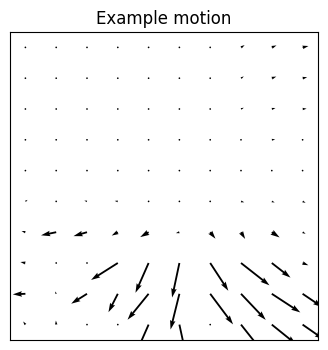

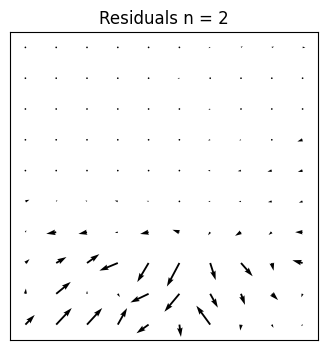

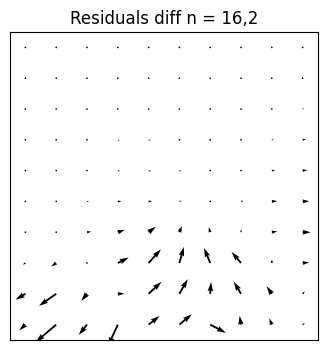

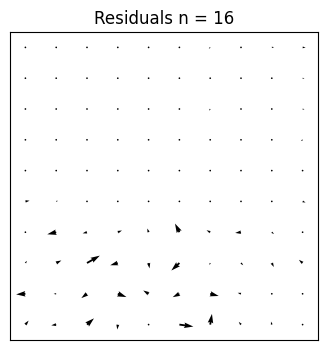

In [9]:
# Reconstruction error for first 100 samples
ind = 8
_ = plot_motion_grid(X_flat[ind], title="Example motion")
err = residual(X_flat[ind:ind+1], n_comp=2)
_ = plot_motion_grid(err[0], title="Residuals n = 2")
err_2 = residual(X_flat[ind:ind+1], n_comp=16)
_ = plot_motion_grid(err_2[0]-err[0], title="Residuals diff n = 16,2")
_ = plot_motion_grid(err_2[0], title="Residuals n = 16")


## Rotational Gradient

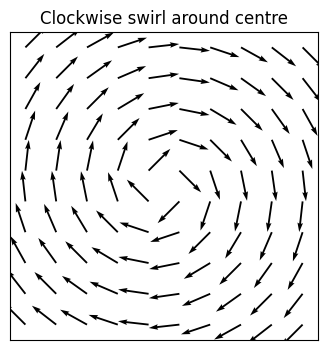

In [10]:
import numpy as np
import matplotlib.pyplot as plt

g = 10
swirl_grid = np.zeros((g, g, 2), dtype=float)

center = np.array([(g - 1) / 2, (g - 1) / 2], dtype=float)  # (4.5, 4.5)

for i in range(g):
    for j in range(g):
        p = np.array([i, j], dtype=float)   # (y, x) = (row, col)
        v = p - center                      # radial in (y, x)
        r = np.linalg.norm(v)
        if r == 0:
            swirl_grid[i, j] = 0.0
        else:
            # Clockwise tangent in (y, x): (vy, vx) -> (vx, -vy)
            t_yx = np.array([v[1], -v[0]]) / r  # still unit length

            # Convert (dy, dx) = (t_yx[0], t_yx[1]) to (dx, dy) for plotting
            swirl_grid[i, j] = np.array([t_yx[1], t_yx[0]])

swirl_flat = swirl_grid.reshape(100, 2)

plot_motion_grid(swirl_flat, title="Clockwise swirl around centre")
plt.show()

In [11]:
rot_scores = radial_alignment_score(X_flat, swirl_flat, mag_thresh=0.0)

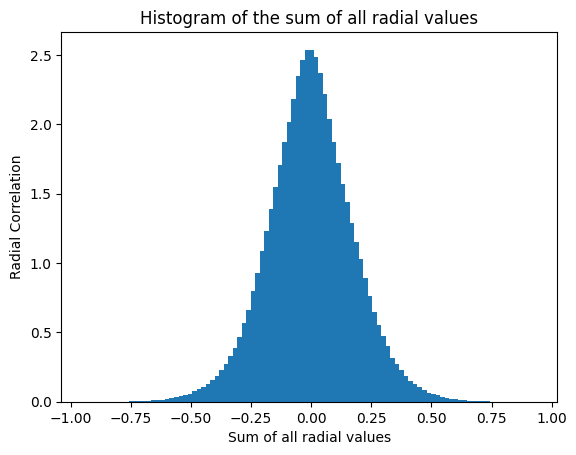

In [12]:
#Plot a histogram of the sum of all dx values
plt.hist(rot_scores, bins=100, density=True)
plt.xlabel("Sum of all radial values")
plt.ylabel("Radial Correlation")
plt.title("Histogram of the sum of all radial values")
plt.show()

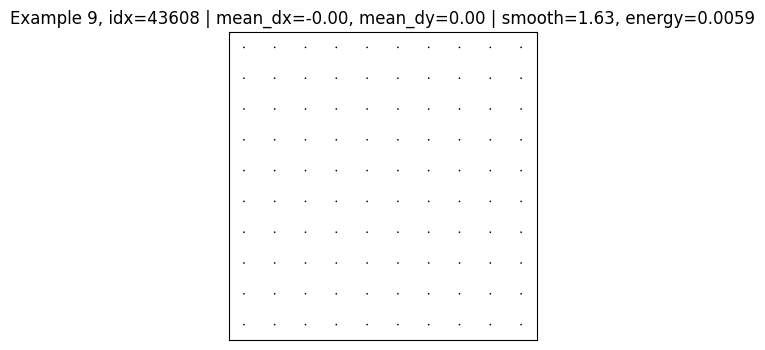

KeyboardInterrupt: 

In [13]:
# Make sure these exist in this session:
# variance = np.var(np.abs(X_flat))   # or whatever you used before
# energy_values = energy(X_flat)

import numpy as np
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

# ---- choose the range you want to inspect ----
dx_min = -0.99
dx_max =  -0.49

# optional controls
max_show = 200          # how many to visualize
shuffle = True          # randomize examples within the range
sleep_s = 0.2

# ---- select indices in the requested range ----
inds = np.where((rot_scores >= dx_min) & (rot_scores <= dx_max))[0]
print(f"Found {len(inds)} samples with sum_dx in [{dx_min}, {dx_max}]")

if len(inds) == 0:
    raise ValueError("No samples in that range. Widen dx_min/dx_max.")

# downsample so you don't loop forever
if shuffle:
    inds = np.random.permutation(inds)
inds = inds[:min(max_show, len(inds))]

for i, ind in enumerate(inds):
    clear_output(wait=True)

    vec = X_flat[ind]           # shape (200,)
    assert vec.shape[0] == 200

    motion = vec.reshape(100, 2)
    dx = motion[:, 0]
    dy = motion[:, 1]

    # per-sample masked means (same logic you had)
    mag = np.hypot(dx, dy)
    mean_mag = mag.mean()
    std_mag = mag.std()
    mask = (mag > mean_mag - std_mag) & (mag < mean_mag + std_mag)

    mean_dx_i = dx[mask].mean() if mask.any() else 0.0
    mean_dy_i = dy[mask].mean() if mask.any() else 0.0

    smooth = float(smoothness(vec))
    nrg = float(energy(vec))

    if smooth > 500:
        continue

    _ = plot_motion_grid(
        vec,
        title=(f"Example {i}, idx={ind} | "
            #    f"sum_dx={sum_dx[ind]:.2f}, sum_dy={sum_dy[ind]:.2f} | "
               f"mean_dx={mean_dx_i:.2f}, mean_dy={mean_dy_i:.2f} | "
               f"smooth={smooth:.2f}, energy={nrg:.4f}")
    )
    plt.show()
    time.sleep(sleep_s)

## Radial Gradient

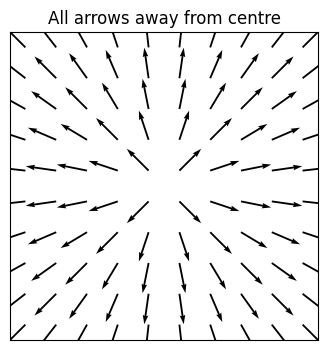

In [14]:
g = 10
radial_grid = np.zeros((g, g, 2), dtype=float)

# Centre of the 10x10 grid in index coordinates
center = np.array([(g - 1) / 2, (g - 1) / 2], dtype=float)  # (4.5, 4.5)

for i in range(g):
    for j in range(g):
        p = np.array([i, j], dtype=float)
        v = p - center              # direction: away from centre
        r = np.linalg.norm(v)
        if r == 0:
            radial_grid[i, j] = 0.0   # or pick any direction, e.g. [1, 0]
        else:
            radial_grid[i, j] = (v / r)[::-1]   # swap (dy, dx) -> (dx, dy)

# Flatten to (100, 2) for plotting
radial_flat = radial_grid.reshape(100, 2)

plot_motion_grid(radial_flat, title="All arrows away from centre")
plt.show()

In [15]:
radial_scores = radial_alignment_score(X_flat, radial_flat, mag_thresh=0.0)

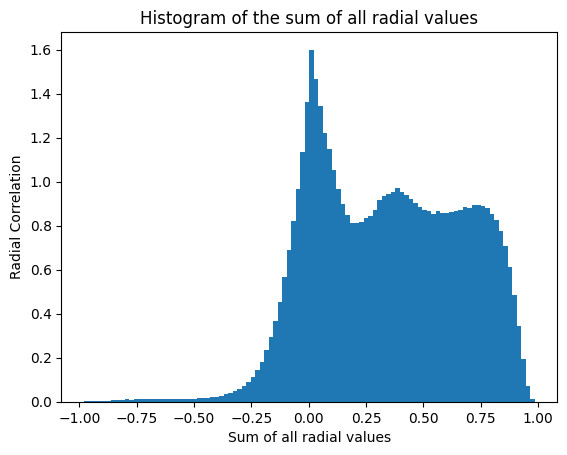

In [ ]:
#Plot a histogram of the sum of all dx values
plt.hist(radial_scores, bins=100, density=True)
plt.xlabel("Sum of all radial values")
plt.ylabel("Radial Correlation")
plt.title("Histogram of the sum of all radial values")
plt.show()

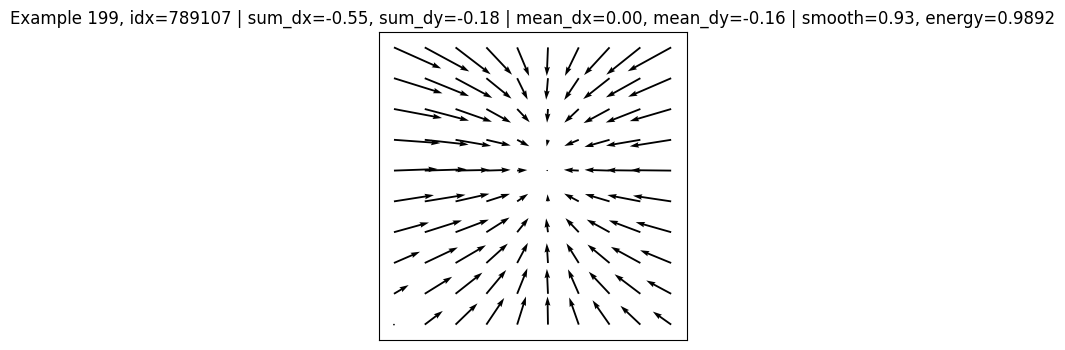

In [ ]:
# Make sure these exist in this session:
# variance = np.var(np.abs(X_flat))   # or whatever you used before
# energy_values = energy(X_flat)

import numpy as np
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

# ---- choose the range you want to inspect ----
dx_min = -0.99
dx_max =  -0.89

# optional controls
max_show = 200          # how many to visualize
shuffle = True          # randomize examples within the range
sleep_s = 0.2

# ---- select indices in the requested range ----
inds = np.where((radial_scores >= dx_min) & (radial_scores <= dx_max))[0]
print(f"Found {len(inds)} samples with sum_dx in [{dx_min}, {dx_max}]")

if len(inds) == 0:
    raise ValueError("No samples in that range. Widen dx_min/dx_max.")

# downsample so you don't loop forever
if shuffle:
    inds = np.random.permutation(inds)
inds = inds[:min(max_show, len(inds))]

for i, ind in enumerate(inds):
    clear_output(wait=True)

    vec = X_flat[ind]           # shape (200,)
    assert vec.shape[0] == 200

    motion = vec.reshape(100, 2)
    dx = motion[:, 0]
    dy = motion[:, 1]

    # per-sample masked means (same logic you had)
    mag = np.hypot(dx, dy)
    mean_mag = mag.mean()
    std_mag = mag.std()
    mask = (mag > mean_mag - std_mag) & (mag < mean_mag + std_mag)

    mean_dx_i = dx[mask].mean() if mask.any() else 0.0
    mean_dy_i = dy[mask].mean() if mask.any() else 0.0

    smooth = float(smoothness(vec))
    nrg = float(energy(vec))

    if smooth > 500:
        continue

    _ = plot_motion_grid(
        vec,
        title=(f"Example {i}, idx={ind} | "
               f"sum_dx={sum_dx[ind]:.2f}, sum_dy={sum_dy[ind]:.2f} | "
               f"mean_dx={mean_dx_i:.2f}, mean_dy={mean_dy_i:.2f} | "
               f"smooth={smooth:.2f}, energy={nrg:.4f}")
    )
    plt.show()
    time.sleep(sleep_s)

## Directional Gradient

In [16]:
all_dx = X_flat[:, 0::2]
all_dy = X_flat[:, 1::2]
sum_dx, sum_dy, mask = masked_sum_dxdy(all_dx, all_dy, k=1.0)

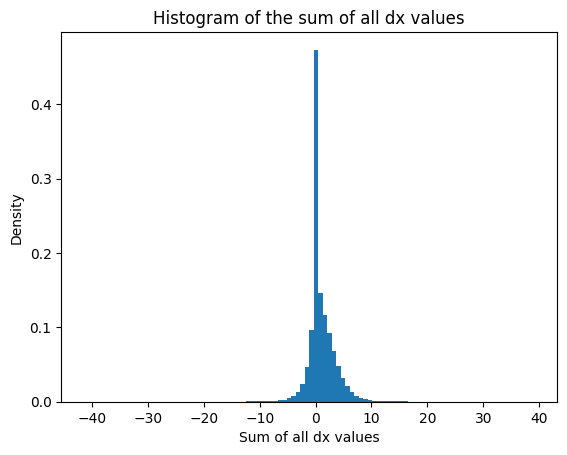

In [17]:
#Plot a histogram of the sum of all dx values
plt.hist(sum_dy, bins=100, density=True)
plt.xlabel("Sum of all dx values")
plt.ylabel("Density")
plt.title("Histogram of the sum of all dx values")
plt.show()


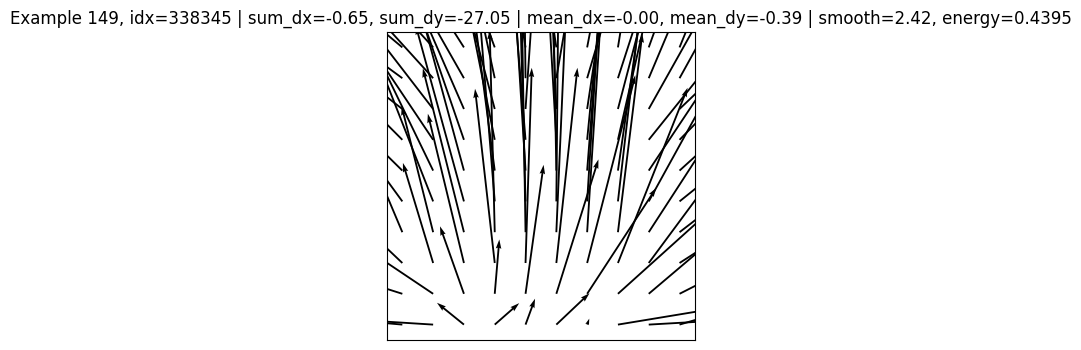

In [ ]:
# Make sure these exist in this session:
# variance = np.var(np.abs(X_flat))   # or whatever you used before
# energy_values = energy(X_flat)

import numpy as np
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

# ---- choose the range you want to inspect ----
dx_min = -35.0
dx_max =  -25.0

# optional controls
max_show = 200          # how many to visualize
shuffle = True          # randomize examples within the range
sleep_s = 0.2

# ---- select indices in the requested range ----
inds = np.where((sum_dy >= dx_min) & (sum_dy <= dx_max))[0]
print(f"Found {len(inds)} samples with sum_dx in [{dx_min}, {dx_max}]")

if len(inds) == 0:
    raise ValueError("No samples in that range. Widen dx_min/dx_max.")

# downsample so you don't loop forever
if shuffle:
    inds = np.random.permutation(inds)
inds = inds[:min(max_show, len(inds))]

for i, ind in enumerate(inds):
    clear_output(wait=True)

    vec = X_flat[ind]           # shape (200,)
    assert vec.shape[0] == 200

    motion = vec.reshape(100, 2)
    dx = motion[:, 0]
    dy = motion[:, 1]

    # per-sample masked means (same logic you had)
    mag = np.hypot(dx, dy)
    mean_mag = mag.mean()
    std_mag = mag.std()
    mask = (mag > mean_mag - std_mag) & (mag < mean_mag + std_mag)

    mean_dx_i = dx[mask].mean() if mask.any() else 0.0
    mean_dy_i = dy[mask].mean() if mask.any() else 0.0

    smooth = float(smoothness(vec))
    nrg = float(energy(vec))

    if smooth > 500:
        continue

    _ = plot_motion_grid(
        vec * variance,
        title=(f"Example {i}, idx={ind} | "
               f"sum_dx={sum_dx[ind]:.2f}, sum_dy={sum_dy[ind]:.2f} | "
               f"mean_dx={mean_dx_i:.2f}, mean_dy={mean_dy_i:.2f} | "
               f"smooth={smooth:.2f}, energy={nrg:.4f}")
    )
    plt.show()
    time.sleep(sleep_s)

## Smoothness and Energy Tests - >500, <0.5

In [18]:
#Return a smoothness value for each sample in X_flat
smoothness_values = smoothness(X_flat)

rand_ind = np.random.randint(0, X_flat.shape[0])
assert smoothness(X_flat[rand_ind]) == smoothness_values[rand_ind]

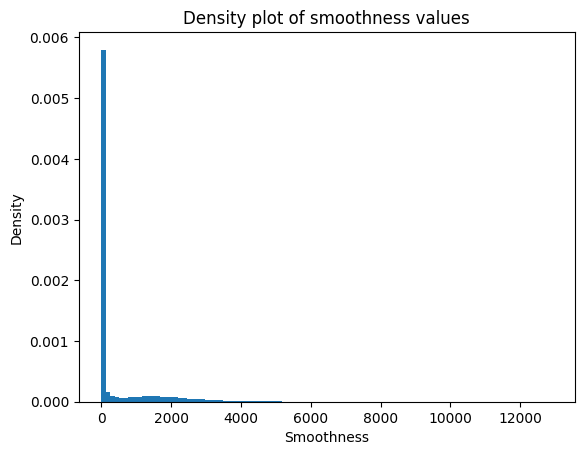

In [ ]:
#Make a density plot of the smoothness values
plt.hist(smoothness_values, bins=100, density=True)
plt.xlabel("Smoothness")
plt.ylabel("Density")
plt.title("Density plot of smoothness values")
plt.show()

In [21]:
#Return a smoothness value for each sample in X_flat
energy_values = energy(X_flat)

rand_ind = np.random.randint(0, X_flat.shape[0])
assert energy(X_flat[rand_ind]) == energy_values[rand_ind]

In [19]:
#Make a density plot of the energy values
plt.hist(energy_values, bins=100, density=True)
plt.xlabel("Energy")
plt.ylabel("Density")
plt.title("Density plot of energy values")
plt.show()

NameError: name 'energy_values' is not defined

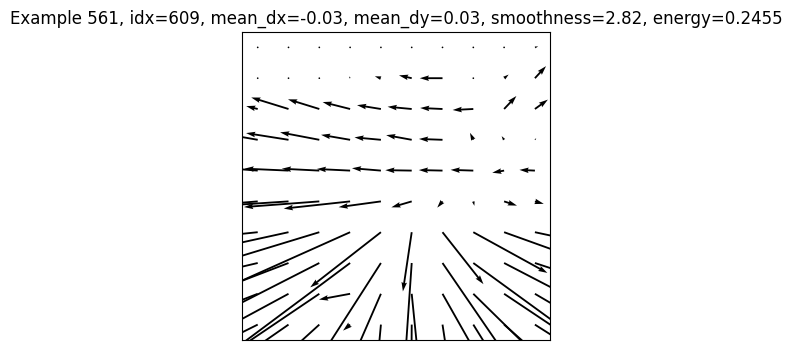

KeyboardInterrupt: 

In [ ]:
# Make sure these exist in this session:
# variance = np.var(np.abs(X_flat))   # or whatever you used before
# energy_values = energy(X_flat)

inds = np.where(energy_values < 0.5)[0]
print(f"Found {len(inds)} motions with energy < 0.01")

for i, ind in enumerate(inds):
    # i= i+80
    clear_output(wait=True)

    vec = X_flat[ind]           # shape (200,)
    assert vec.shape[0] == 200  # sanity check

    motion = vec.reshape(100, 2)
    dx = motion[:, 0]
    dy = motion[:, 1]

    mag = np.sqrt(dx**2 + dy**2)
    mean_mag = mag.mean()
    std_mag = mag.std()

    mask = (mag > mean_mag - std_mag) & (mag < mean_mag + std_mag)
    mean_dx = dx[mask].mean() if mask.any() else 0.0
    mean_dy = dy[mask].mean() if mask.any() else 0.0

    smooth = float(smoothness(vec))
    nrg = float(energy(vec))

    if smooth > 500:
        continue

    _ = plot_motion_grid(
        vec * variance,
        title=(f"Example {i}, idx={ind}, "
               f"mean_dx={mean_dx:.2f}, mean_dy={mean_dy:.2f}, "
               f"smoothness={smooth:.2f}, energy={nrg:.4f}")
    )
    plt.show()
    time.sleep(0.2)

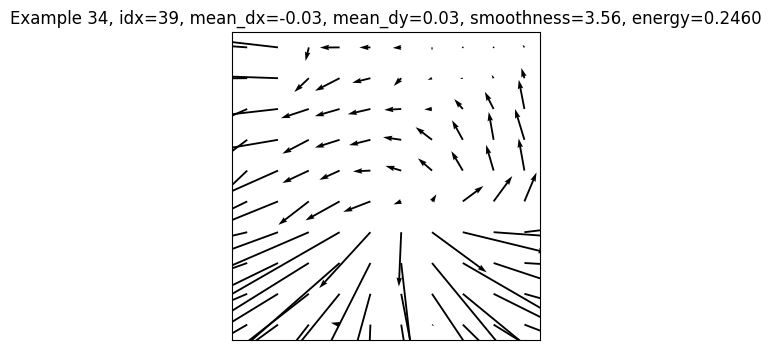

KeyboardInterrupt: 

In [ ]:
# Make sure these exist in this session:
# variance = np.var(np.abs(X_flat))   # or whatever you used before
# energy_values = energy(X_flat)

inds = np.where(smoothness_values < 100)[0]
print(f"Found {len(inds)} motions with energy < 0.01")

for i, ind in enumerate(inds):
    # i= i+80
    clear_output(wait=True)

    vec = X_flat[ind]           # shape (200,)
    assert vec.shape[0] == 200  # sanity check

    motion = vec.reshape(100, 2)
    dx = motion[:, 0]
    dy = motion[:, 1]

    mag = np.sqrt(dx**2 + dy**2)
    mean_mag = mag.mean()
    std_mag = mag.std()

    mask = (mag > mean_mag - std_mag) & (mag < mean_mag + std_mag)
    mean_dx = dx[mask].mean() if mask.any() else 0.0
    mean_dy = dy[mask].mean() if mask.any() else 0.0

    smooth = float(smoothness(vec))
    nrg = float(energy(vec))

    _ = plot_motion_grid(
        vec * variance,
        title=(f"Example {i}, idx={ind}, "
               f"mean_dx={mean_dx:.2f}, mean_dy={mean_dy:.2f}, "
               f"smoothness={smooth:.2f}, energy={nrg:.4f}")
    )
    plt.show()
    time.sleep(0.2)

# Scatter Plot

In [ ]:
#Find out where energy_values are below 0.5 and smoothness is above 500 to get the label of 0
inds = np.where((energy_values < 0.5) & (smoothness_values > 500))[0]
labels = np.zeros(X_flat.shape[0])
labels[inds] = 1

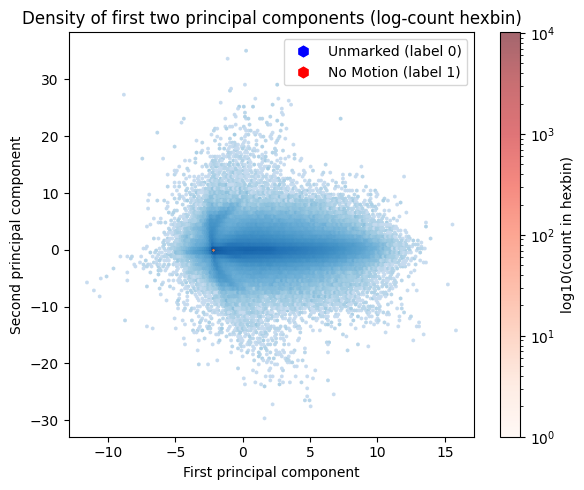

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def truncate_cmap(cmap, minval=0.25, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval},{maxval})",
        cmap(np.linspace(minval, maxval, n))
    )

x = transformed[:, 0]
y = transformed[:, 1]

m0 = (labels == 0)
m1 = (labels == 1)

plt.figure(figsize=(6, 5))

# Density via hexbin (2D histogram). bins="log" makes dense regions visible.
hb0 = plt.hexbin(x[m0], y[m0],
                gridsize=160, mincnt=1, bins="log",
                cmap="Blues", alpha=0.60)

hb1 = plt.hexbin(x[m1], y[m1],
                gridsize=160, mincnt=1, bins="log",
                cmap="Reds", alpha=0.60)

plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("Density of first two principal components (log-count hexbin)")

# Optional: a colorbar for “log10(counts per hex)”
cbar = plt.colorbar(hb1)
cbar.set_label("log10(count in hexbin)")

# Legend (keeps your discrete label meaning)
legend_elems = [
    Line2D([0], [0], marker="h", color="w", markerfacecolor="blue",
           markersize=10, label="Unmarked (label 0)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor="red",
           markersize=10, label="No Motion (label 1)"),
]
plt.legend(handles=legend_elems, loc="best")

blue_cmap = truncate_cmap(plt.cm.Blues, minval=0.25)
red_cmap  = truncate_cmap(plt.cm.Reds,  minval=0.25)

x, y = transformed[:, 0], transformed[:, 1]
m0, m1 = labels == 0, labels == 1

hb0 = plt.hexbin(x[m0], y[m0],
                gridsize=160, mincnt=1,
                cmap=blue_cmap, norm=LogNorm(vmin=1), alpha=0.9)

hb1 = plt.hexbin(x[m1], y[m1],
                gridsize=160, mincnt=1,
                cmap=red_cmap, norm=LogNorm(vmin=1), alpha=0.9)

plt.tight_layout()
plt.show()

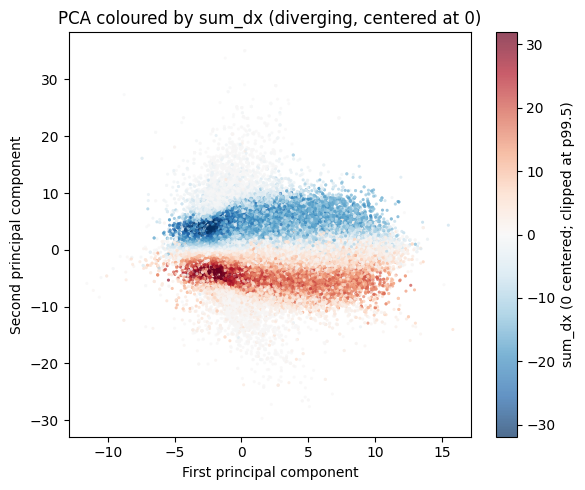

In [ ]:
scatter_by_value(
    transformed, sum_dx,
    title="PCA coloured by sum_dx (diverging, centered at 0)",
    cbar_label="sum_dx (0 centered; clipped at p99.5)",
    diverging=True,
    vmax=np.percentile(np.abs(sum_dx), 99.5),
)

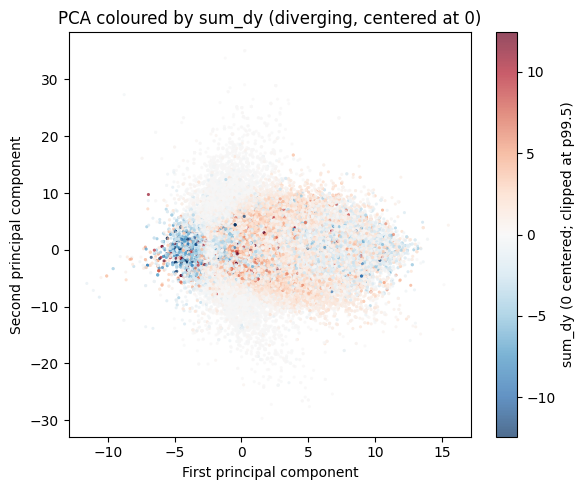

In [ ]:
scatter_by_value(
    transformed, sum_dy,
    title="PCA coloured by sum_dy (diverging, centered at 0)",
    cbar_label="sum_dy (0 centered; clipped at p99.5)",
    diverging=True,
    vmax=np.percentile(np.abs(sum_dy), 99.5),
)

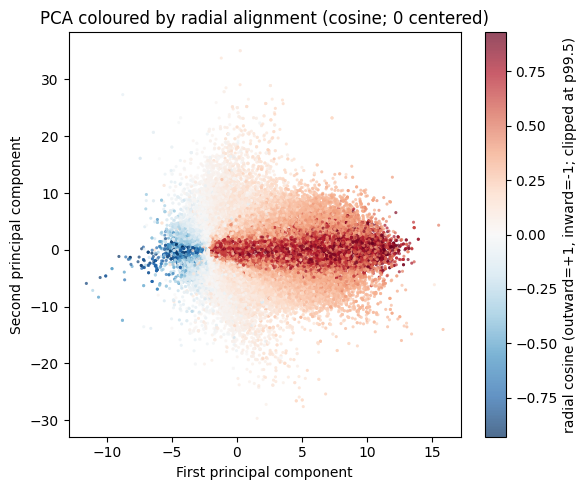

In [ ]:
scatter_by_value(
    transformed, radial_scores,
    title="PCA coloured by radial alignment (cosine; 0 centered)",
    cbar_label="radial cosine (outward=+1, inward=-1; clipped at p99.5)",
    diverging=True,
    vmax=min(1.0, np.percentile(np.abs(radial_scores), 99.5)),
)

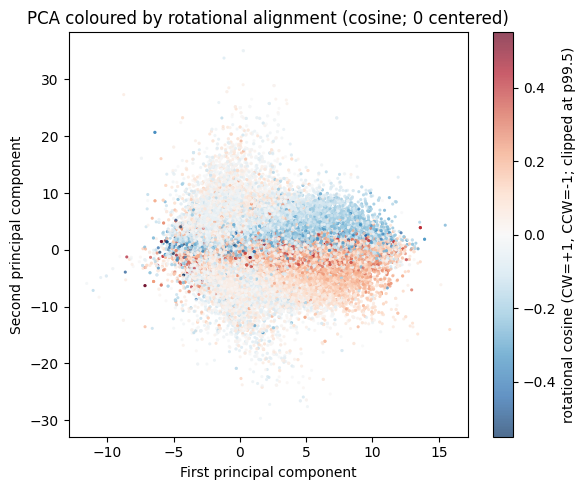

In [ ]:
# 1) Rotational alignment (cosine)
scatter_by_value(
    transformed, rot_scores,
    title="PCA coloured by rotational alignment (cosine; 0 centered)",
    cbar_label="rotational cosine (CW=+1, CCW=-1; clipped at p99.5)",
    diverging=True,
    vmax=min(1.0, np.percentile(np.abs(rot_scores), 99.5)),
)

## Free Visualise

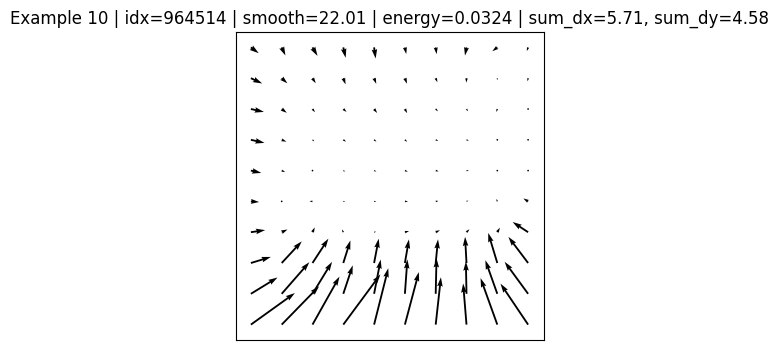

In [ ]:
inds_right = select_radius(transformed, cx=-9, cy=-1, r=2)

slideshow_from_inds(
    X_flat/15, inds_right,
    variance=variance,
    sleep_s=0.2,
    max_show=200,
    shuffle=True,
    smoothness_fn=smoothness,
    energy_fn=energy,
    smooth_max=500,
    extra_title_fn=lambda ind: f"sum_dx={sum_dx[ind]:.2f}, sum_dy={sum_dy[ind]:.2f}"
)